# Homework 2

Viraj Dua

DSCI 552: Machine Learning

In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# Keep tables and plots easy to read.
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

PREDICTORS = ["AT", "V", "AP", "RH"]
RANDOM_STATE = 42


def format_p(p):
    return "<0.0001" if p < 0.0001 else f"{p:.4f}"

## 1. Combined Cycle Power Plant Data Set

### (a) Load the data

The supplied workbook contains five shuffled versions of the same data. As instructed, I use only `Sheet1`.

In [2]:
data_path = Path("CCPP/Folds5x2_pp.xlsx")
df = pd.read_excel(data_path, sheet_name="Sheet1")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Explore the data

#### i. Rows and columns

There are 9,568 rows and 5 columns. Each row is one hourly observation of the power plant. `AT`, `V`, `AP`, and `RH` are the predictors, and `PE` is the net hourly electrical energy output to be predicted.

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("Missing values:", df.isna().sum().sum())

Rows: 9,568
Columns: 5
Missing values: 0


#### ii. Pairwise scatterplots

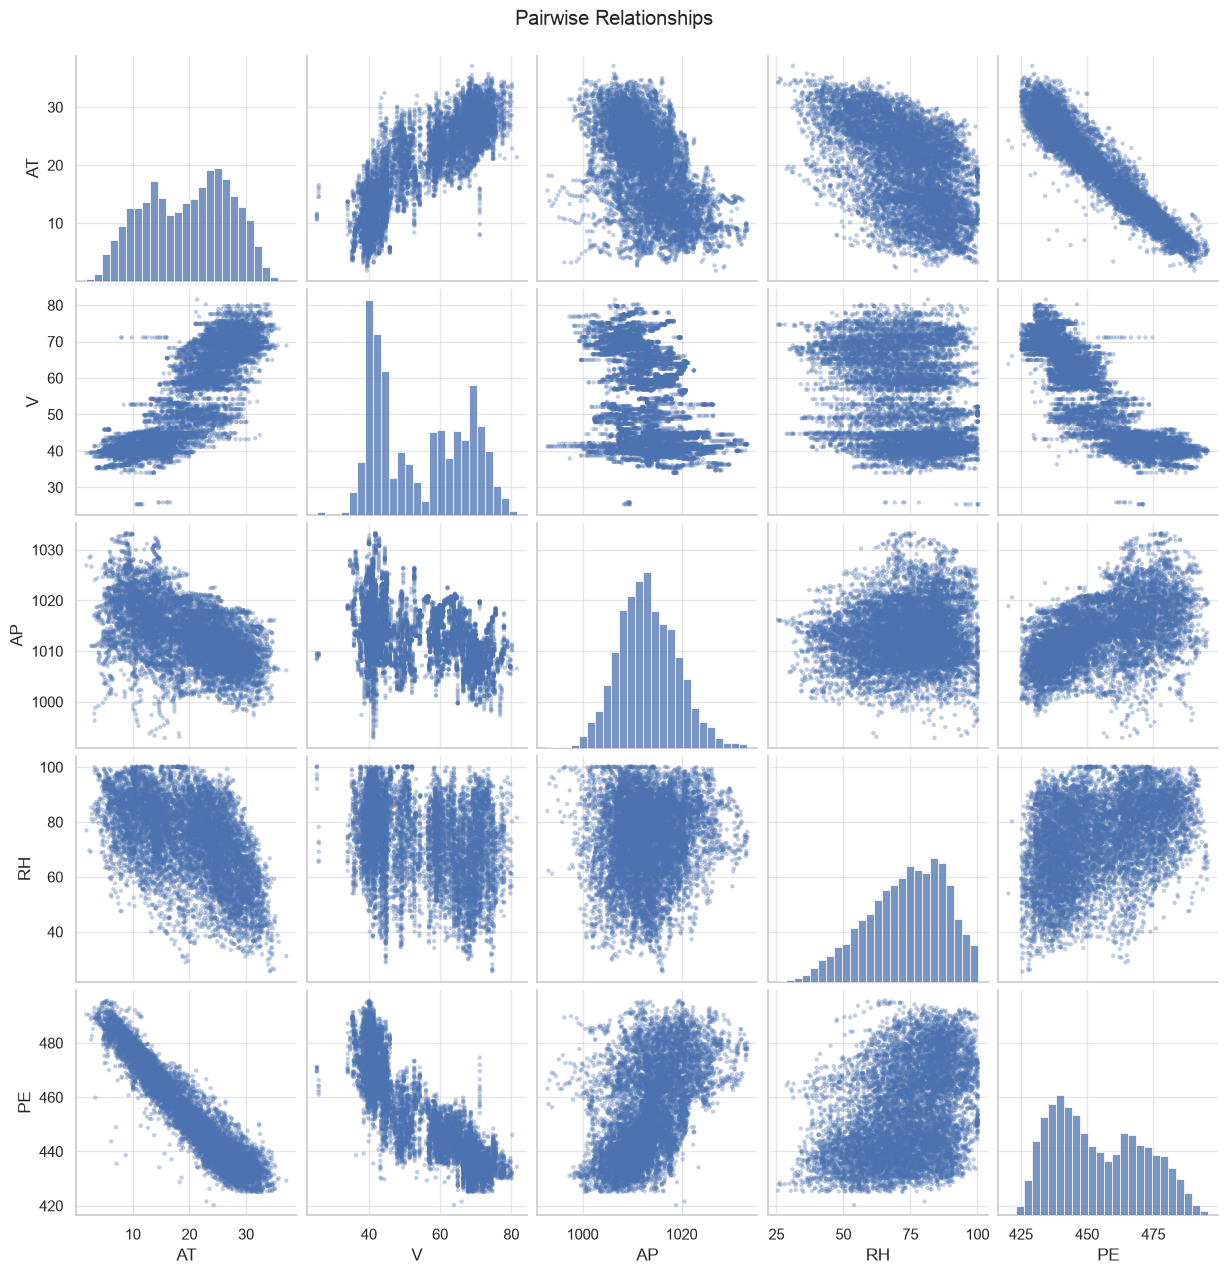

In [4]:
g = sns.pairplot(
    df,
    diag_kind="hist",
    plot_kws={"s": 10, "alpha": 0.35, "edgecolor": "none"},
    diag_kws={"bins": 25},
)
g.fig.suptitle("Pairwise Relationships", y=1.02)
plt.show()

`PE` decreases strongly as `AT` and `V` increase, with the clearest relationship appearing for `AT`. When examined on their own, `AP` and `RH` have weaker positive relationships with `PE`. Some curvature is visible, especially for `AT`. Also, `AT` and `V` are strongly related to each other, so their estimated effects may change when they are included in the same model.

#### iii. Summary statistics

In [5]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
})
summary["IQR"] = summary["Q3"] - summary["Q1"]
summary.round(2)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


### (c) Simple linear regression

In [6]:
simple_models = {
    x: smf.ols(f"PE ~ {x}", data=df).fit()
    for x in PREDICTORS
}

simple_results = pd.DataFrame({
    x: {
        "Coefficient": model.params[x],
        "Std. Error": model.bse[x],
        "p-value": model.pvalues[x],
        "R-squared": model.rsquared,
    }
    for x, model in simple_models.items()
}).T

simple_display = simple_results.copy()
simple_display["p-value"] = simple_display["p-value"].map(format_p)
display(simple_display.round(4))

,Coefficient,Std. Error,p-value,R-squared
AT,-2.1713,0.0074,<0.0001,0.8989
V,-1.1681,0.0068,<0.0001,0.7565
AP,1.4899,0.0251,<0.0001,0.2688
RH,0.4557,0.0110,<0.0001,0.1519


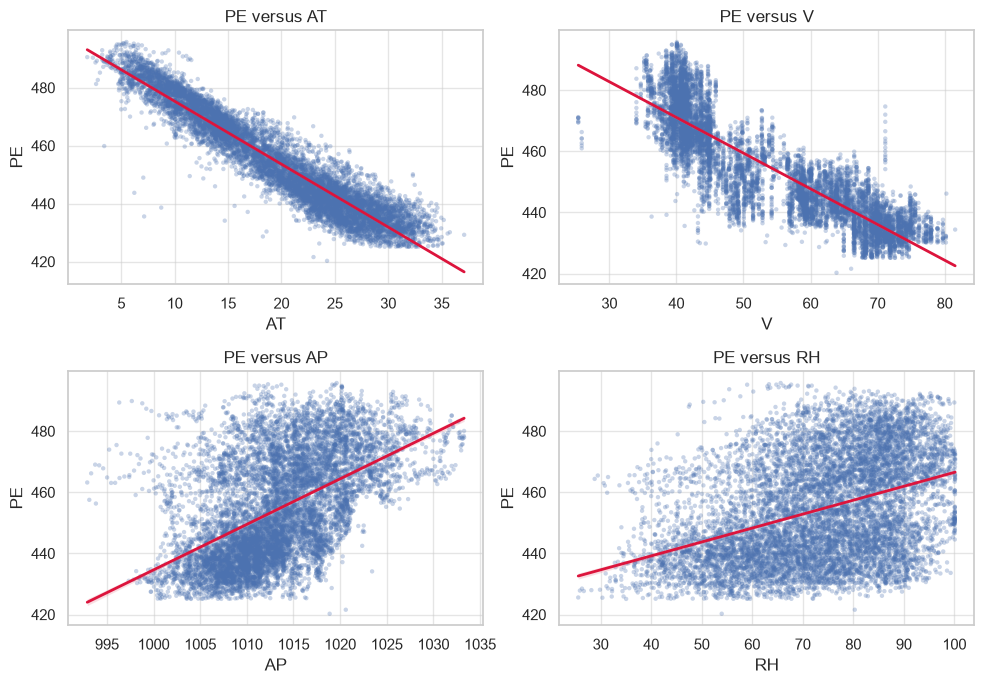

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for x, ax in zip(PREDICTORS, axes.flat):
    sns.regplot(
        data=df,
        x=x,
        y="PE",
        scatter_kws={"s": 10, "alpha": 0.3, "edgecolor": "none"},
        line_kws={"color": "crimson", "linewidth": 2},
        ax=ax,
    )
    ax.set_title(f"PE versus {x}")

plt.tight_layout()
plt.show()

At the 5% level, all four predictors are significantly related to `PE`. `AT` is the strongest single predictor (R-squared is about 0.899), followed by `V` (about 0.757). `AP` and `RH` explain much less variation on their own. A few observations have larger residuals, but none appears to be a clear data error or strong enough reason for removal, so I keep all observations.

### (d) Multiple linear regression

In [8]:
multiple_model = smf.ols("PE ~ AT + V + AP + RH", data=df).fit()

multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "Std. Error": multiple_model.bse,
    "t-statistic": multiple_model.tvalues,
    "p-value": multiple_model.pvalues,
})
multiple_display = multiple_results.copy()
multiple_display["p-value"] = multiple_display["p-value"].map(format_p)

display(multiple_display.round(4))
print(f"R-squared: {multiple_model.rsquared:.4f}")
print(f"Adjusted R-squared: {multiple_model.rsquared_adj:.4f}")

,Coefficient,Std. Error,t-statistic,p-value
Intercept,454.6093,9.7485,46.6337,<0.0001
AT,-1.9775,0.0153,-129.3420,<0.0001
V,-0.2339,0.0073,-32.1221,<0.0001
AP,0.0621,0.0095,6.5641,<0.0001
RH,-0.1581,0.0042,-37.9185,<0.0001


R-squared: 0.9287
Adjusted R-squared: 0.9287


The model explains 92.87% of the variation in `PE`. Every predictor has a p-value below 0.05, so I reject `H0: beta_j = 0` for `AT`, `V`, `AP`, and `RH`.

### (e) Simple versus multiple regression coefficients

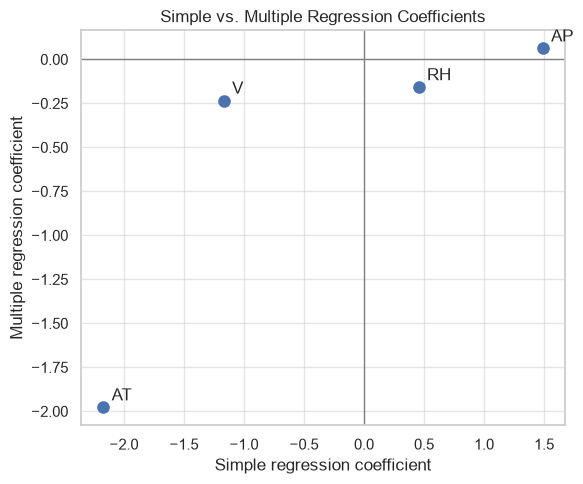

,Simple,Multiple
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


In [9]:
coefficient_comparison = pd.DataFrame({
    "Simple": [simple_models[x].params[x] for x in PREDICTORS],
    "Multiple": [multiple_model.params[x] for x in PREDICTORS],
}, index=PREDICTORS)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    coefficient_comparison["Simple"],
    coefficient_comparison["Multiple"],
    s=65,
)
for name, row in coefficient_comparison.iterrows():
    ax.annotate(name, (row["Simple"], row["Multiple"]), xytext=(6, 5),
                textcoords="offset points")
ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0, color="gray", linewidth=1)
ax.set(xlabel="Simple regression coefficient",
       ylabel="Multiple regression coefficient",
       title="Simple vs. Multiple Regression Coefficients")
plt.tight_layout()
plt.show()

coefficient_comparison.round(4)

The coefficients change after accounting for the other predictors. The largest changes are for `AP` and `RH`, and the coefficient for `RH` changes from positive to negative. Because the predictors are related to one another, a simple regression does not fully separate one predictor's effect from the effects of the others.

### (f) Nonlinear associations

In [10]:
polynomial_models = {}
polynomial_rows = []

for x in PREDICTORS:
    # Standardizing X keeps the fitted cubic curve the same and avoids numerical issues.
    z = (df[x] - df[x].mean()) / df[x].std()
    model = smf.ols("PE ~ z + I(z ** 2) + I(z ** 3)",
                    data=df.assign(z=z)).fit()
    polynomial_models[x] = model
    polynomial_rows.append({
        "Predictor": x,
        "Linear p-value": model.pvalues["z"],
        "Quadratic p-value": model.pvalues["I(z ** 2)"],
        "Cubic p-value": model.pvalues["I(z ** 3)"],
        "R-squared": model.rsquared,
    })

polynomial_results = pd.DataFrame(polynomial_rows).set_index("Predictor")
polynomial_display = polynomial_results.copy()
for column in polynomial_display.columns[:3]:
    polynomial_display[column] = polynomial_display[column].map(format_p)
display(polynomial_display.round(4))

,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
Predictor,,,,
AT,<0.0001,<0.0001,<0.0001,0.9119
V,<0.0001,<0.0001,0.0137,0.7750
AP,<0.0001,<0.0001,<0.0001,0.2975
RH,<0.0001,0.1014,<0.0001,0.1537


For every predictor, the cubic term has a p-value below 0.05, suggesting that a straight line does not capture the full relationship with `PE`. The improvement is largest for `AT`; adding nonlinear terms for `RH` changes R-squared very little.

### (g) Pairwise interactions

In [11]:
interaction_model = smf.ols("PE ~ (AT + V + AP + RH) ** 2", data=df).fit()
interaction_names = [name for name in interaction_model.params.index if ":" in name]

interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_names],
    "p-value": interaction_model.pvalues[interaction_names],
})
interaction_display = interaction_results.copy()
interaction_display["p-value"] = interaction_display["p-value"].map(format_p)
display(interaction_display.round(4))

,Coefficient,p-value
AT:V,0.0210,<0.0001
AT:AP,0.0018,0.4521
AT:RH,-0.0052,<0.0001
V:AP,0.0068,<0.0001
V:RH,0.0008,0.0862
AP:RH,-0.0016,0.0336


At the 5% level, the significant interaction terms are `AT:V`, `AT:RH`, `V:AP`, and `AP:RH`. The `AT:AP` and `V:RH` interactions are not significant. This suggests that the relationship between one predictor and `PE` can change depending on another predictor.

### (h) Linear and expanded regression models

I use the same random 70/30 split for both models. The expanded model starts with the original predictors, their squared terms, and all pairwise interactions. I then remove the least significant squared or interaction term one at a time until the remaining terms have p-values below 0.05. When keeping a squared or interaction term, I also keep the related original predictors.

In [12]:
train, test = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
)

linear_model = smf.ols("PE ~ AT + V + AP + RH", data=train).fit()

# Standardize using only the training data before creating squares and interactions.
means = train[PREDICTORS].mean()
stds = train[PREDICTORS].std()
train_z = train.copy()
test_z = test.copy()
train_z[PREDICTORS] = (train[PREDICTORS] - means) / stds
test_z[PREDICTORS] = (test[PREDICTORS] - means) / stds

square_terms = [f"I({x} ** 2)" for x in PREDICTORS]
interaction_terms = [f"{a}:{b}" for a, b in combinations(PREDICTORS, 2)]
terms = PREDICTORS + square_terms + interaction_terms

removed = []
while True:
    formula = "PE ~ " + " + ".join(terms)
    expanded_model = smf.ols(formula, data=train_z).fit()
    extra_terms = [term for term in terms if term not in PREDICTORS]
    pvalues = expanded_model.pvalues[extra_terms]

    if pvalues.max() <= 0.05:
        break

    worst_term = pvalues.idxmax()
    removed.append({"Removed term": worst_term, "p-value": pvalues[worst_term]})
    terms.remove(worst_term)

removal_table = pd.DataFrame(removed)
removal_table["p-value"] = removal_table["p-value"].map(format_p)
display(removal_table)
print("Kept squared and interaction terms:")
print(", ".join(term for term in terms if term not in PREDICTORS))

,Removed term,p-value
0,V:RH,0.8674
1,I(V ** 2),0.6077
2,V:AP,0.3578


Kept squared and interaction terms:
I(AT ** 2), I(AP ** 2), I(RH ** 2), AT:V, AT:AP, AT:RH, AP:RH


In [13]:
regression_mse = pd.DataFrame([
    {
        "Model": "Multiple linear regression",
        "Train MSE": mean_squared_error(train["PE"], linear_model.predict(train)),
        "Test MSE": mean_squared_error(test["PE"], linear_model.predict(test)),
    },
    {
        "Model": "Selected quadratic and interaction model",
        "Train MSE": mean_squared_error(train_z["PE"], expanded_model.predict(train_z)),
        "Test MSE": mean_squared_error(test_z["PE"], expanded_model.predict(test_z)),
    },
]).set_index("Model")

regression_mse.round(4)

,Train MSE,Test MSE
Model,,
Multiple linear regression,20.5808,21.2399
Selected quadratic and interaction model,17.8908,18.6600


The multiple linear regression model has a test MSE of 21.24, while the model with selected squared and interaction terms has a lower test MSE of 18.66. For the selected model, the training MSE of 17.89 is close to the test MSE of 18.66, suggesting no severe overfitting.

### (i) KNN regression

In [14]:
X_train = train[PREDICTORS]
X_test = test[PREDICTORS]
y_train = train["PE"]
y_test = test["PE"]
k_values = np.arange(1, 101)


def knn_errors(X_train, X_test):
    train_errors, test_errors = [], []
    for k in k_values:
        model = KNeighborsRegressor(n_neighbors=k)
        model.fit(X_train, y_train)
        train_errors.append(mean_squared_error(y_train, model.predict(X_train)))
        test_errors.append(mean_squared_error(y_test, model.predict(X_test)))
    return np.array(train_errors), np.array(test_errors)


raw_train_mse, raw_test_mse = knn_errors(X_train, X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scaled_train_mse, scaled_test_mse = knn_errors(X_train_scaled, X_test_scaled)

best_raw_k = int(k_values[np.argmin(raw_test_mse)])
best_scaled_k = int(k_values[np.argmin(scaled_test_mse)])

knn_summary = pd.DataFrame([
    {
        "Features": "Raw",
        "Best k": best_raw_k,
        "Train MSE": raw_train_mse[best_raw_k - 1],
        "Test MSE": raw_test_mse[best_raw_k - 1],
    },
    {
        "Features": "Normalized",
        "Best k": best_scaled_k,
        "Train MSE": scaled_train_mse[best_scaled_k - 1],
        "Test MSE": scaled_test_mse[best_scaled_k - 1],
    },
]).set_index("Features")

display(knn_summary.round(4))

,Best k,Train MSE,Test MSE
Features,,,
Raw,5,10.6008,15.7268
Normalized,4,8.5914,14.3057


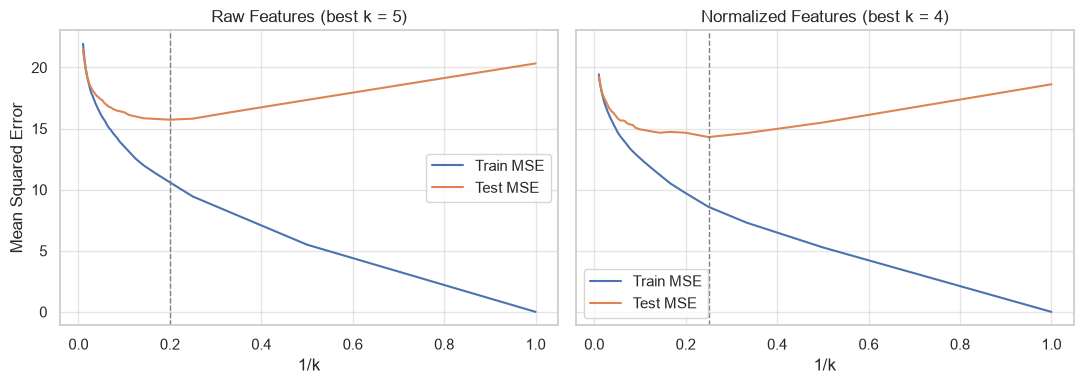

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, title, train_errors, test_errors, best_k in [
    (axes[0], "Raw Features", raw_train_mse, raw_test_mse, best_raw_k),
    (axes[1], "Normalized Features", scaled_train_mse, scaled_test_mse, best_scaled_k),
]:
    ax.plot(1 / k_values, train_errors, label="Train MSE")
    ax.plot(1 / k_values, test_errors, label="Test MSE")
    ax.axvline(1 / best_k, color="gray", linestyle="--", linewidth=1)
    ax.set(xlabel="1/k", title=f"{title} (best k = {best_k})")
    ax.legend()

axes[0].set_ylabel("Mean Squared Error")
plt.tight_layout()
plt.show()

The best raw-feature model uses k = 5, while the best normalized model uses k = 4. Normalization improves KNN because variables measured with larger numbers would otherwise have more influence on distance.

### (j) KNN versus linear regression

In [16]:
best_regression_name = regression_mse["Test MSE"].idxmin()
best_regression_mse = regression_mse["Test MSE"].min()
best_knn_name = knn_summary["Test MSE"].idxmin()
best_knn_mse = knn_summary["Test MSE"].min()

comparison = pd.DataFrame({
    "Model": [best_regression_name, f"KNN ({best_knn_name.lower()} features)"],
    "Test MSE": [best_regression_mse, best_knn_mse],
}).set_index("Model")

display(comparison.round(4))
improvement = 100 * (best_regression_mse - best_knn_mse) / best_regression_mse
print(f"Normalized KNN has {improvement:.1f}% lower test MSE on this split.")

,Test MSE
Model,
Selected quadratic and interaction model,18.6600
KNN (normalized features),14.3057


Normalized KNN has 23.3% lower test MSE on this split.


Normalized KNN has the lowest test MSE, so it gives the best predictions for this split. The selected regression model is easier to explain because its coefficients and p-values show how the predictors, squared terms, and interactions relate to `PE`.

## 2. ISLR 2.4.1

| Case | Flexible method | Reason |
|---|---|---|
| (a) Very large `n`, small `p` | Better | The large sample provides enough data for a flexible method without a high risk of overfitting. |
| (b) Very large `p`, small `n` | Worse | A flexible method is likely to overfit because there are many predictors but few observations. |
| (c) Highly nonlinear relationship | Better | A flexible method can follow the nonlinear pattern, while an inflexible method may miss it. |
| (d) Very high error variance | Worse | A flexible method is more likely to fit random noise and perform poorly on new data. |

## 3. ISLR 2.4.7

The test point is `(0, 0, 0)`, so each distance is the Euclidean distance from an observation to the origin.

| Observation | Distance | Class |
|---:|---:|---|
| 1 | `sqrt(0^2 + 3^2 + 0^2) = 3.000` | Red |
| 2 | `sqrt(2^2 + 0^2 + 0^2) = 2.000` | Red |
| 3 | `sqrt(0^2 + 1^2 + 3^2) = sqrt(10) = 3.162` | Red |
| 4 | `sqrt(0^2 + 1^2 + 2^2) = sqrt(5) = 2.236` | Green |
| 5 | `sqrt((-1)^2 + 0^2 + 1^2) = sqrt(2) = 1.414` | Green |
| 6 | `sqrt(1^2 + 1^2 + 1^2) = sqrt(3) = 1.732` | Red |

**(b)** With `K = 1`, the nearest observation is observation 5, so the prediction is **Green**.

**(c)** With `K = 3`, the nearest observations are 5 (Green), 6 (Red), and 2 (Red). The majority class is therefore **Red**.

**(d)** If the Bayes decision boundary is highly nonlinear, a **small K** is preferable because it can follow the nonlinear shape more closely. A large K would average over too many points and smooth out that shape.
